In [1]:
# Simulation / bootstrapping and Fixed Effects

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import root_mean_squared_error

## Fixed Effects

In [3]:
scipy.stats.norm.rvs(0, 1, (5,))

array([ 1.81757259, -0.01843587,  0.15056101,  0.35591514,  0.39689771])

In [4]:
num = 1000

X1 = scipy.stats.norm.rvs(0, 1, (num,))
X2 = scipy.stats.norm.rvs(0, 1, (num,))
X3 = scipy.stats.norm.rvs(0, 1, (num,))

Y1 = 3 * X1 + 5 + scipy.stats.norm.rvs(0, 1, (num,))
Y2 = 3 * X2 + 10 + scipy.stats.norm.rvs(0, 1, (num,))
Y3 = 3 * X3 + 15 + scipy.stats.norm.rvs(0, 1, (num,))

In [5]:
results = sm.OLS(Y1, sm.add_constant(X1)).fit()

In [6]:
results.params

array([4.98205554, 3.02299084])

In [7]:
results.bse

array([0.03254341, 0.03400272])

In [8]:
results.rsquared

0.8878902065701583

In [9]:
np.std(results.resid)

1.0280784313633764

In [10]:
np.std(results.resid) # (resid_0 - resid_mean)^2 + (resid_1 - resid_mean)^2 + ....

1.0280784313633764

In [11]:
root_mean_squared_error(Y1, results.predict(sm.add_constant(X1))) # Another way
# (resid_0)^2 + (resid_1)^2 + ....

1.0280784313633764

In [12]:
results.resid.mean()

-1.91491267287347e-15

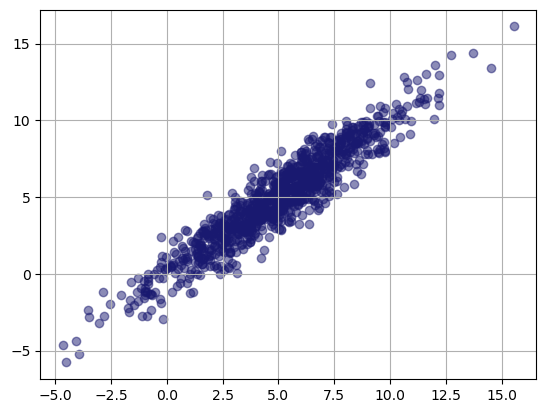

In [13]:
plt.scatter(
    results.predict(sm.add_constant(X1)),
    Y1,
    c = 'midnightblue',
    alpha = 0.5
    )
plt.grid()

In [14]:
Y = np.hstack((Y1, Y2, Y3))
X = np.hstack((X1, X2, X3))

results_combined = sm.OLS(Y, sm.add_constant(X)).fit()
results_combined.params # note that params do not match group 1, but likely will match group 2

array([10.00516811,  3.03825289])

In [15]:
results_combined.bse

array([0.07708179, 0.07731871])

In [16]:
results_combined.rsquared # rsquared is _worse_ than for group 1 alone

0.3399545758450261

In [17]:
np.std(results_combined.resid)

4.220240227859407

In [18]:
root_mean_squared_error(Y, results_combined.predict(sm.add_constant(X))) # another way

4.220240227859407

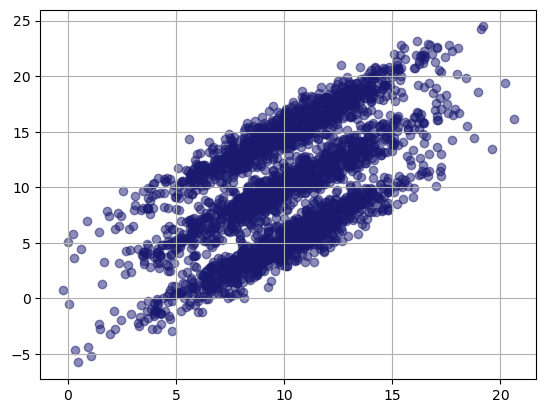

In [19]:
plt.scatter(results_combined.predict(sm.add_constant(X)),
            Y, 
            c = 'midnightblue', 
            alpha = 0.5
            )
# plt.tight_layout()
plt.grid()

In [20]:
pd.get_dummies(np.repeat([0, 1, 2], 5), drop_first = True)

,1,2
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,True,False
6,True,False
7,True,False
8,True,False
9,True,False


In [21]:
groups                  = np.repeat([0, 1, 2], num)
X_fixed_effects         = pd.get_dummies(groups, drop_first=True)
X_design                = np.hstack((X.reshape(-1, 1), X_fixed_effects))
df_design               = pd.DataFrame(X_design, columns = ["X", "Group_1", "Group_2"])
results_fixed_effects   = sm.OLS(Y, sm.add_constant(df_design)).fit()

In [22]:
results_fixed_effects.params

const       4.981953
X           2.988623
Group_1     5.041942
Group_2    10.029459
dtype: float64

In [23]:
results_fixed_effects.bse

const      0.032390
X          0.018760
Group_1    0.045807
Group_2    0.045809
dtype: float64

In [24]:
results_fixed_effects.rsquared

0.9611726692473583

In [25]:
np.std(results_fixed_effects.resid)

1.0235734874050728

In [26]:
root_mean_squared_error(Y, results_fixed_effects.predict(sm.add_constant(df_design)))

1.0235734874050733

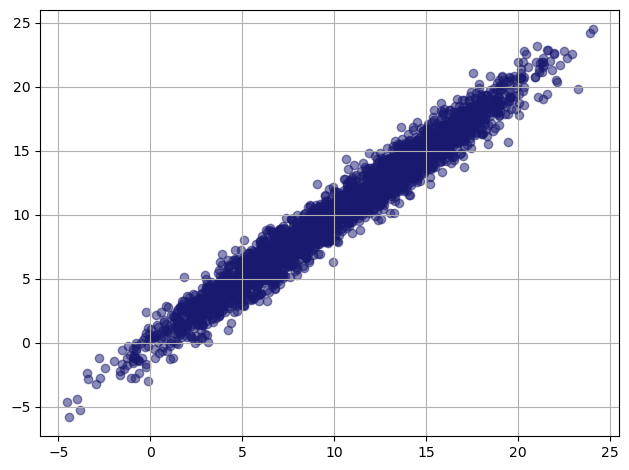

In [27]:
plt.scatter(results_fixed_effects.predict(sm.add_constant(df_design)), 
            Y, 
            c = 'midnightblue', 
            alpha = 0.5
            )
plt.tight_layout()
plt.grid()

In [28]:
X = np.hstack((X1 - X1.mean(), X2 - X2.mean(), X3 - X3.mean()))
Y = np.hstack((Y1 - Y1.mean(), Y2 - Y2.mean(), Y3 - Y3.mean()))

results_demeaned = sm.OLS(Y, X).fit()

In [29]:
results_demeaned.rsquared

0.8944100845414402

In [30]:
np.std(results_demeaned.resid)

1.0235734874050733

In [31]:
root_mean_squared_error(Y, results_demeaned.predict(X))

1.0235734874050733

# Simulation

In [32]:
# Suppose we want to know what happens if we do this simulation many times
num_iter    = 1000
beta_1_list = list()
se_list     = list()

for n in range(num_iter):
    num = 1000
    X1 = scipy.stats.norm.rvs(0, 1, (num,))
    X2 = scipy.stats.norm.rvs(0, 1, (num,))
    X3 = scipy.stats.norm.rvs(0, 1, (num,))

    Y1 = 3 * X1 + 5 + scipy.stats.norm.rvs(0, 1, (num,))
    Y2 = 3 * X2 + 10 + scipy.stats.norm.rvs(0, 1, (num,))
    Y3 = 3 * X3 + 15 + scipy.stats.norm.rvs(0, 1, (num,))

    X = np.hstack((X1 - X1.mean(), X2 - X2.mean(), X3 - X3.mean())) # demean the data
    Y = np.hstack((Y1 - Y1.mean(), Y2 - Y2.mean(), Y3 - Y3.mean()))
    
    results_demeaned = sm.OLS(Y, X).fit()
    beta_1_list.append(results_demeaned.params[0])
    se_list.append(results_demeaned.bse[0])

np.std(beta_1_list)

0.01809442250484707

In [33]:
np.std(beta_1_list), np.mean(beta_1_list)

(0.01809442250484707, 2.9995758072508183)

In [34]:
np.std(se_list), np.mean(se_list)

(0.0003420666931483756, 0.01825790656940383)

In [35]:
np.mean(beta_1_list)

2.9995758072508183

(array([  3.,   3.,  12.,  18.,  31.,  51.,  76., 105., 107., 128., 122.,
        108., 102.,  62.,  30.,  20.,  10.,   8.,   2.,   2.]),
 array([2.94310645, 2.94893423, 2.95476201, 2.96058979, 2.96641756,
        2.97224534, 2.97807312, 2.9839009 , 2.98972868, 2.99555645,
        3.00138423, 3.00721201, 3.01303979, 3.01886756, 3.02469534,
        3.03052312, 3.0363509 , 3.04217867, 3.04800645, 3.05383423,
        3.05966201]),
 <BarContainer object of 20 artists>)

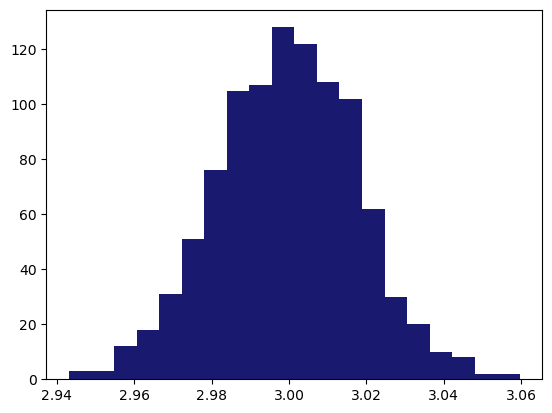

In [36]:
plt.hist(beta_1_list, bins = 20, color = 'midnightblue')
# plt.tight_layout()

(array([  1.,   0.,   1.,   2.,  11.,  30.,  39.,  67.,  82., 138., 144.,
        151., 121.,  78.,  55.,  37.,  18.,  11.,   6.,   8.]),
 array([0.01695037, 0.01707005, 0.01718974, 0.01730942, 0.01742911,
        0.01754879, 0.01766847, 0.01778816, 0.01790784, 0.01802753,
        0.01814721, 0.01826689, 0.01838658, 0.01850626, 0.01862595,
        0.01874563, 0.01886531, 0.018985  , 0.01910468, 0.01922437,
        0.01934405]),
 <BarContainer object of 20 artists>)

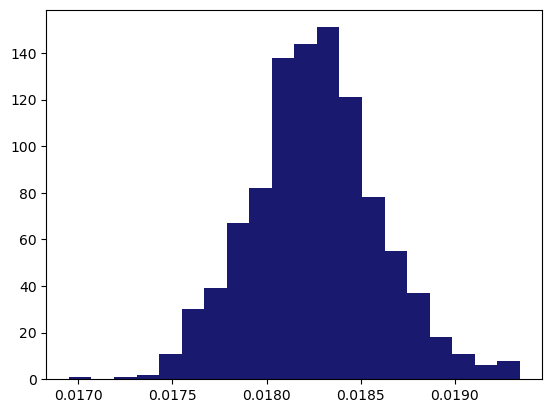

In [37]:
plt.hist(se_list, bins = 20, color = 'midnightblue')